In [2]:
from SGD import SGD, LambdaSGD, MomentumSGD, NesterovSGD, AdaGrad, RMSProp
from BasicGD import Polynomial, MonomialParam
import matplotlib.pyplot as plt
from GradGraph import Variable
import math
import numpy as np #importing ONLY for drawing the gradient field

# Helpers and setup

In [3]:
#MSE helper functions
def np_mse(true, pred):
    true = np.atleast_2d(true)
    pred = np.atleast_2d(pred)
    return np.sqrt(
        np.mean(
            (pred-true)**2,
            axis=-1)
    )
def batch_mse(x: list, y:list):
    #Assumes both lists are of the same length
    squared_error = [(x[i]-y[i])**2 for i in range(len(x))]
    mean_squared_error = 0
    for elem in squared_error:
        mean_squared_error += elem
    mean_squared_error /= len(squared_error)
    return mean_squared_error

In [56]:
#batch helpers
#simple batching generator for dataset
def batchmaker(dataset, batchsize):
    total_points = len(dataset)
    cur_idx = 0
    while cur_idx + batchsize <= total_points:
        yield dataset[cur_idx:cur_idx+batchsize], true_vals[cur_idx:cur_idx+batchsize]
        cur_idx += batchsize
    if cur_idx < total_points:
        yield dataset[cur_idx:], true_vals[cur_idx:]
#makes cosine annealing lambda based on epochs and batchsize
def make_lam(epochs, batchsize=None):
    if batchsize is None:
        num_steps = epochs
    else:
        num_steps = math.ceil(len(true_vals) / batchsize) * epochs
    lam = lambda x: math.cos(x * math.pi / (2 * num_steps))
    return lam

In [5]:
#pre-processing for 3d gradient map
np_dset = np.linspace(-5, 5, 100)
np_true = np_dset + np_dset **2 #simulating poly
coeff_x, coeff_y = np.linspace(0, 1.1, 100), np.linspace(0,1.1,100)
X, Y = np.meshgrid(coeff_x, coeff_y, indexing='ij')
preds = X[:,:,None]*np_dset[None,None,:] + Y[:,:,None]*np_dset[None,None,:]**2
np_err =  np_mse(np_true[None,None,:], preds)

In [6]:
#pre-processing for testing purposes
true_lin, true_sq = 1,1
test_poly = Polynomial(coefficients=[true_lin, true_sq], degrees=[1,2])
num_points = 100
dataset = [-5 + (10*i)/num_points for i in range(num_points)]
true_vals = [test_poly(point) for point in dataset]

In [7]:
def plot_vals(lin_coeffs, sq_coeffs, sgd_poly):
    true_vals = [test_poly(point) for point in dataset]
    pred_vals = [sgd_poly(point) for point in dataset]
    fig = plt.figure(figsize=(10,10))
    ax_params = fig.add_subplot(221)
    ax_params.scatter(lin_coeffs, sq_coeffs, s=1, c=range(len(lin_coeffs)))
    ax2d = fig.add_subplot(222)
    ax2d.scatter(dataset, [val.v for val in true_vals], c="red")
    ax2d.scatter(dataset, [val.v for val in pred_vals], c="blue")
    ax2d.set_title("Test Values vs Pred Values")
    ax3d = fig.add_subplot(2,2,(3,4), projection='3d', computed_zorder = False)
    ax3d.plot_surface(X, Y, np_err, cmap="winter_r", zorder=1)
    ax3d.view_init(elev=20, azim=20)
    np_lin = np.array(lin_coeffs)
    np_sq = np.array(sq_coeffs)
    preds = np_lin[:,None] * np_dset[None,:] + np_sq[:,None] * np_dset[None,:]**2
    local_error = np_mse(preds, np_true)
    ax3d.scatter(lin_coeffs, sq_coeffs, local_error+2.5, marker='o', cmap="seismic_r", s=10, c=range(len(lin_coeffs)), zorder=5)
    ax3d.set_title("Error landscape")

In [8]:
#test runners that allow for fullbatch and minibatch implementations
def run_test(polynomial, optim, num_epochs=500, tol=0.01, batch_size = None):
    if batch_size is None:
        batch_size = len(dataset)
    #lam = lambda x: math.cos(x * math.pi/(2*num_epochs))
    #optim = LambdaSGD(sgd_poly.get_params(), lr=0.001, lr_func = lam)
    lin_coeffs = []
    sq_coeffs = []
    lin_term, sq_term = polynomial.get_params()
    lin_coeffs.append(lin_term.coeff.v)
    sq_coeffs.append(sq_term.coeff.v)
    steps = 0
    stop = False
    for i in range(num_epochs):
        if stop==True: break
        batcher = batchmaker(dataset, batch_size)
        for batch, targets in batcher:
            pred_vals = [sgd_poly(point) for point in batch]
            loss = batch_mse(targets, pred_vals)
            loss.backward()
            optim.update_params()
            steps += 1
            lin_term, sq_term = polynomial.get_params()
            lin_coeffs.append(lin_term.coeff.v)
            sq_coeffs.append(sq_term.coeff.v)
            lin_err = abs(lin_term.coeff.v - true_lin)
            sq_err = abs(sq_term.coeff.v - true_sq)
            if lin_err < tol*true_lin and sq_err < tol*true_sq:
                print(f"Optimization converged at epoch {i+1} with {steps} steps")
                stop = True
                break
    if not stop:
        print(f"Optimization did not converge, stopped within {lin_err:.3%} of linear and, {sq_err:.3%} of squared terms with {tol:.3%} tolerance")
    plot_vals(lin_coeffs, sq_coeffs, polynomial)

# (Lambda)SGD

Optimization converged at epoch 250 with 250 steps


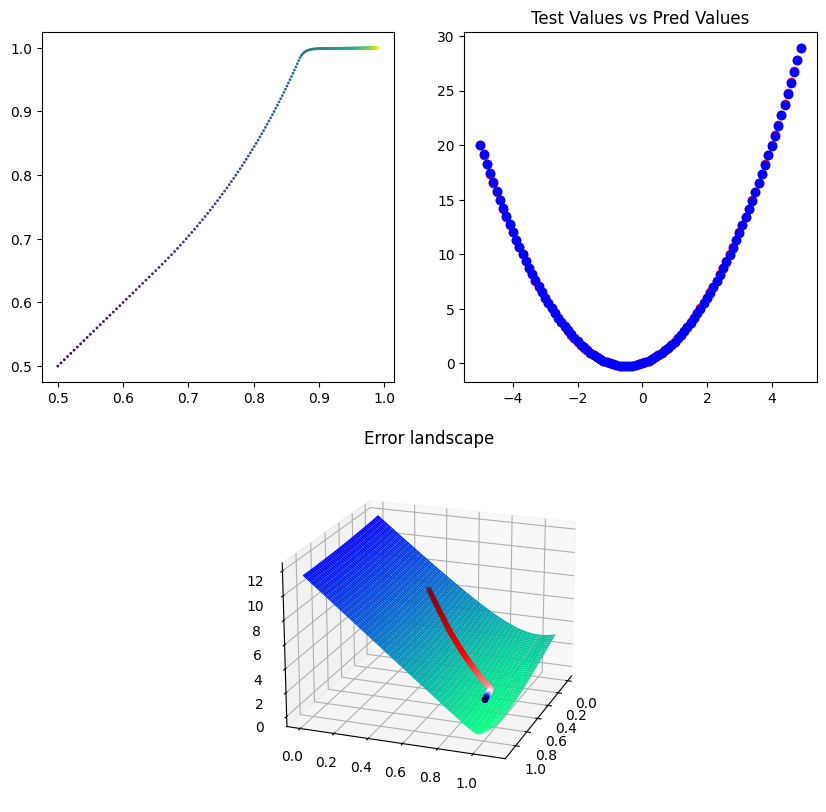

In [9]:
#Full batch SGD
sgd_poly = Polynomial(coefficients=[0.5,0.5], degrees=[1,2])
optim = SGD(sgd_poly.get_params(), lr=0.001)
run_test(sgd_poly, optim)

Optimization converged at epoch 22 with 421 steps


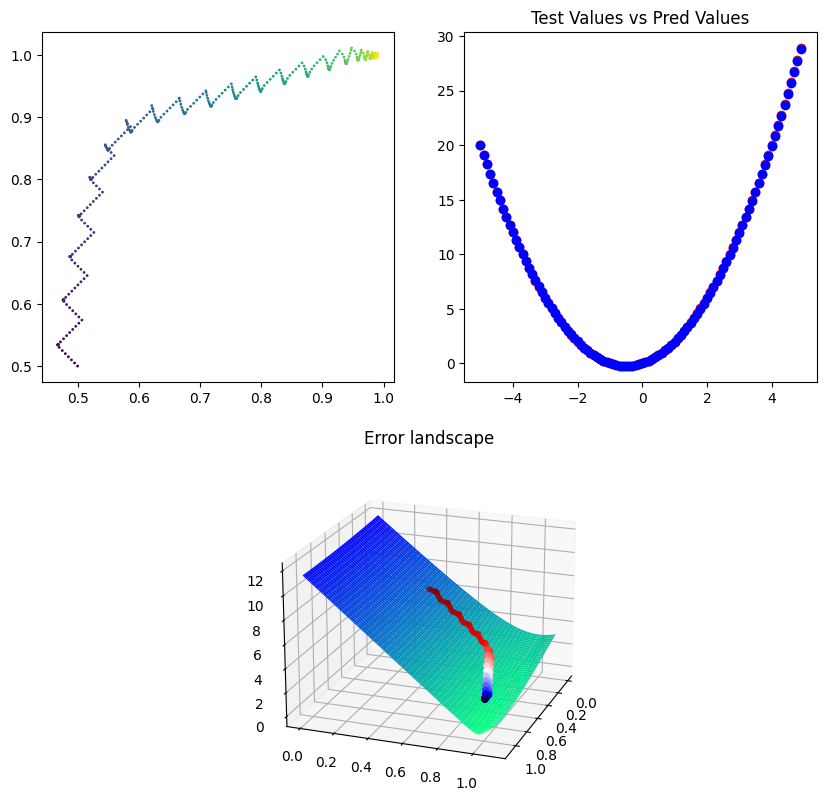

In [10]:
#minibatch sgd
sgd_poly = Polynomial(coefficients=[0.5,0.5], degrees=[1,2])
optim = SGD(sgd_poly.get_params(), lr=0.001)
run_test(sgd_poly, optim, num_epochs=22, batch_size=5)

Optimization converged at epoch 30 with 30 steps


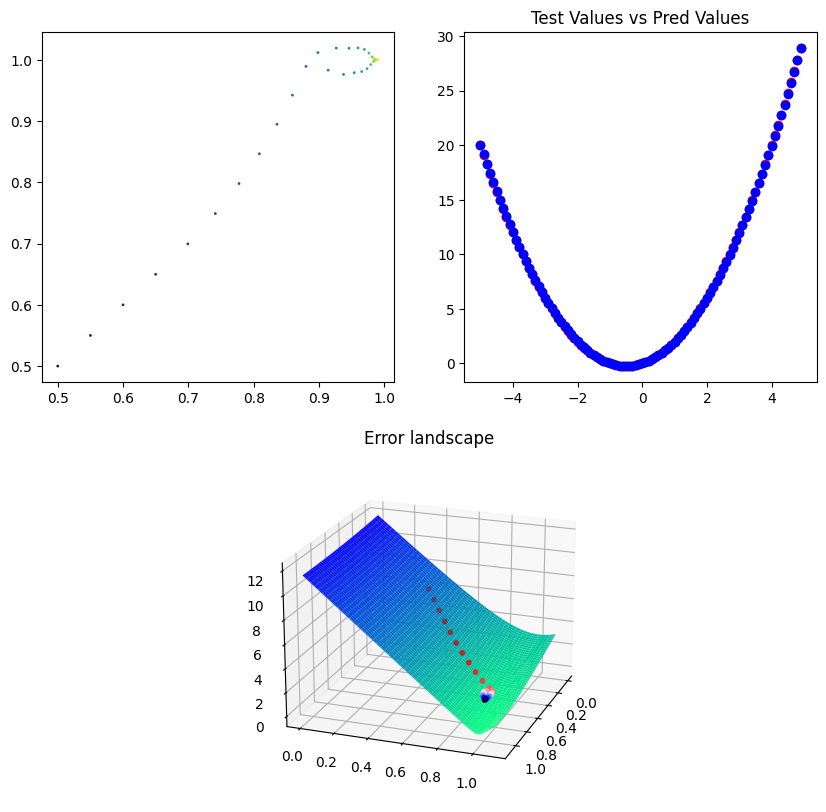

In [11]:
#Full batch LambdaSGD
sgd_poly = Polynomial(coefficients=[0.5,0.5], degrees=[1,2])
num_epochs = 40
lam = lambda x: math.cos(x * math.pi/(2*num_epochs))
optim = LambdaSGD(sgd_poly.get_params(), lr=0.01, lr_func=lam)
run_test(sgd_poly, optim, num_epochs=num_epochs)

Optimization converged at epoch 13 with 49 steps


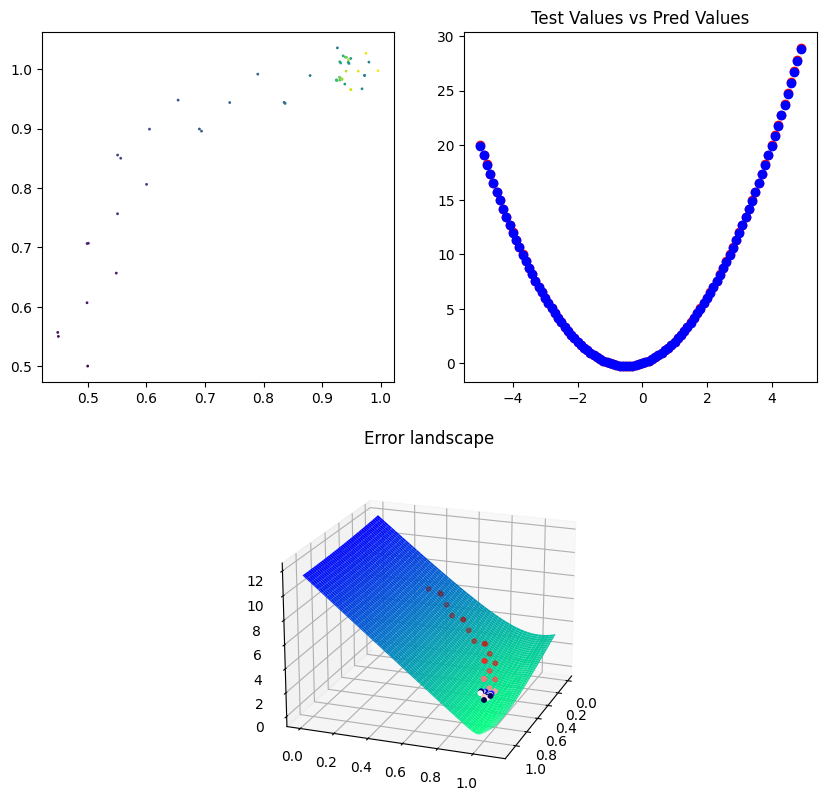

In [12]:
#minibatchbatch LambdaSGD
sgd_poly = Polynomial(coefficients=[0.5, 0.5], degrees=[1, 2])
batch_size = 30
num_epochs = 20
batch_num = math.ceil(len(true_vals) / batch_size)
lam = lambda x: math.cos(x * math.pi / (2 * num_epochs * batch_num))
optim = LambdaSGD(sgd_poly.get_params(), lr=0.01, lr_func=lam)
run_test(sgd_poly, optim, num_epochs=num_epochs, batch_size=batch_size, tol=0.01)

# (Nesterov)MomentumSGD

Optimization converged at epoch 16 with 16 steps


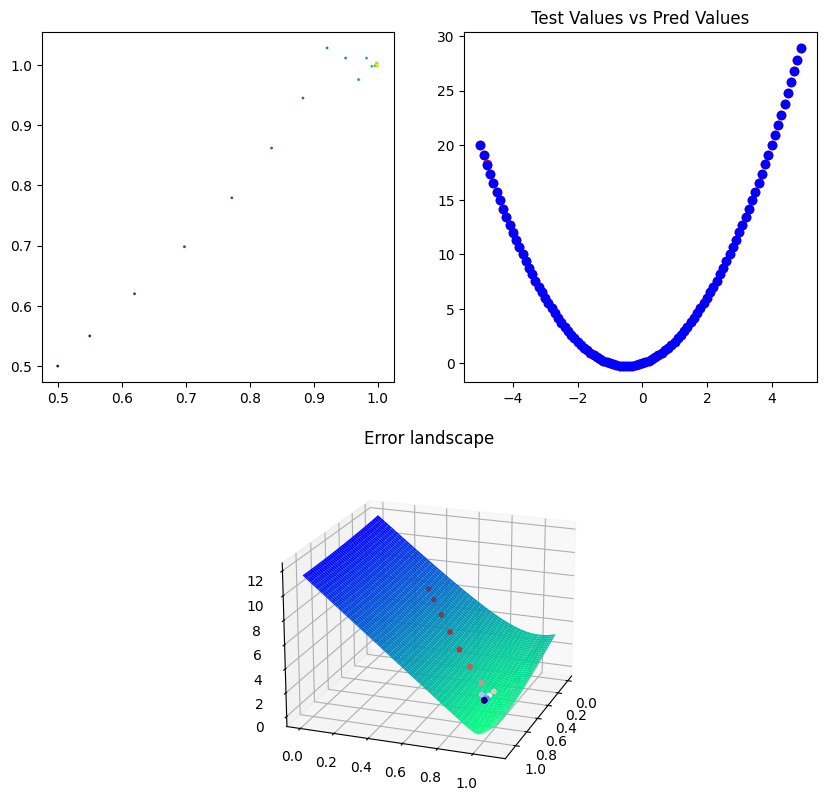

In [13]:
#Full batch MomentumSGD no annealing
sgd_poly = Polynomial(coefficients=[0.5,0.5], degrees=[1,2])
num_epochs = 20
optim = MomentumSGD(sgd_poly.get_params(), lr=0.01, momentum=0.4, lr_func=None)
run_test(sgd_poly, optim, num_epochs=num_epochs, tol=0.001)

Optimization converged at epoch 15 with 15 steps


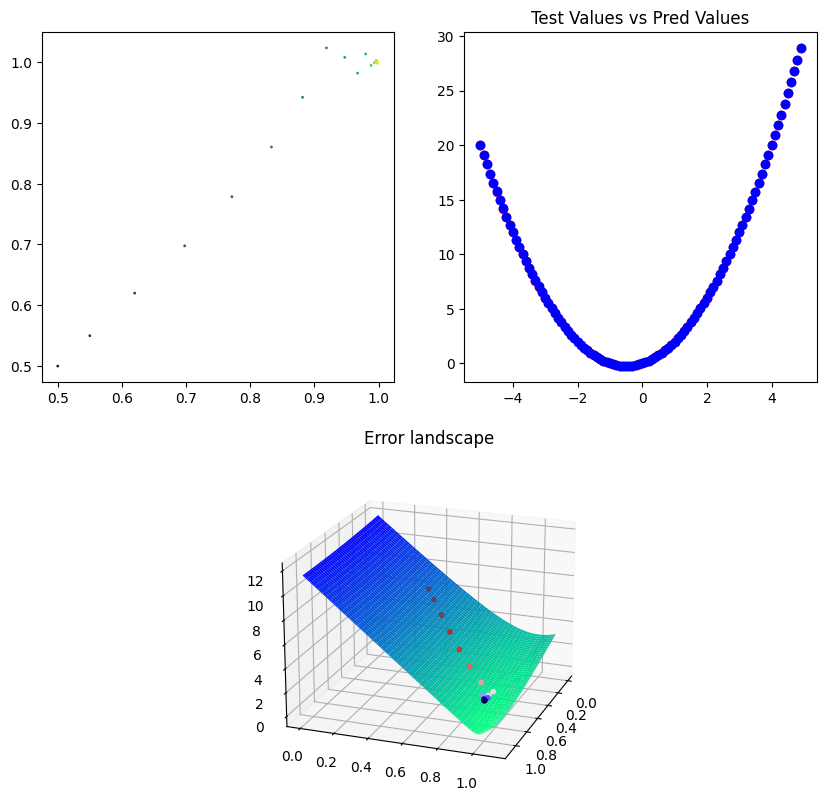

In [14]:
#Full batch MomentumSGD with annealing
sgd_poly = Polynomial(coefficients=[0.5, 0.5], degrees=[1, 2])
num_epochs = 40
lam = lambda x: math.cos(x * math.pi / (2 * num_epochs))
optim = MomentumSGD(sgd_poly.get_params(), lr=0.01, momentum=0.4, lr_func=lam)
run_test(sgd_poly, optim, num_epochs=num_epochs, tol=0.001)

Optimization converged at epoch 5 with 97 steps


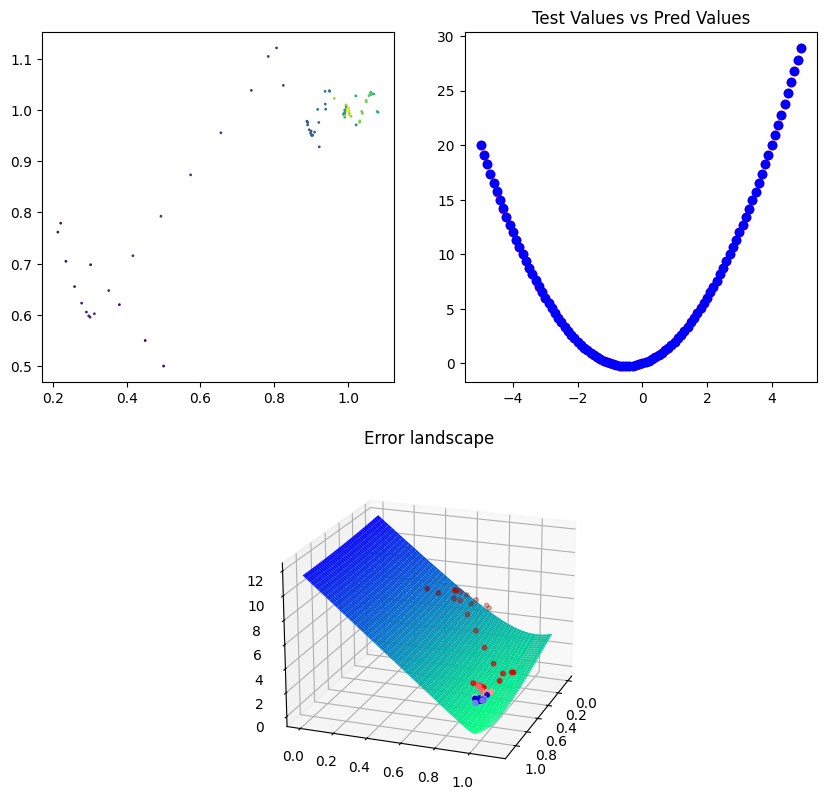

In [15]:
#minibatch MomentumSGD
sgd_poly = Polynomial(coefficients=[0.5, 0.5], degrees=[1, 2])
batch_size = 5
num_epochs = 20
batch_num = math.ceil(len(true_vals) / batch_size)
lam = lambda x: math.cos(x * math.pi / (2 * num_epochs * batch_num))
optim = MomentumSGD(sgd_poly.get_params(), lr=0.01, momentum=0.4, lr_func=lam)
run_test(sgd_poly, optim, num_epochs=num_epochs, batch_size=batch_size, tol=0.001)

Optimization converged at epoch 3 with 41 steps


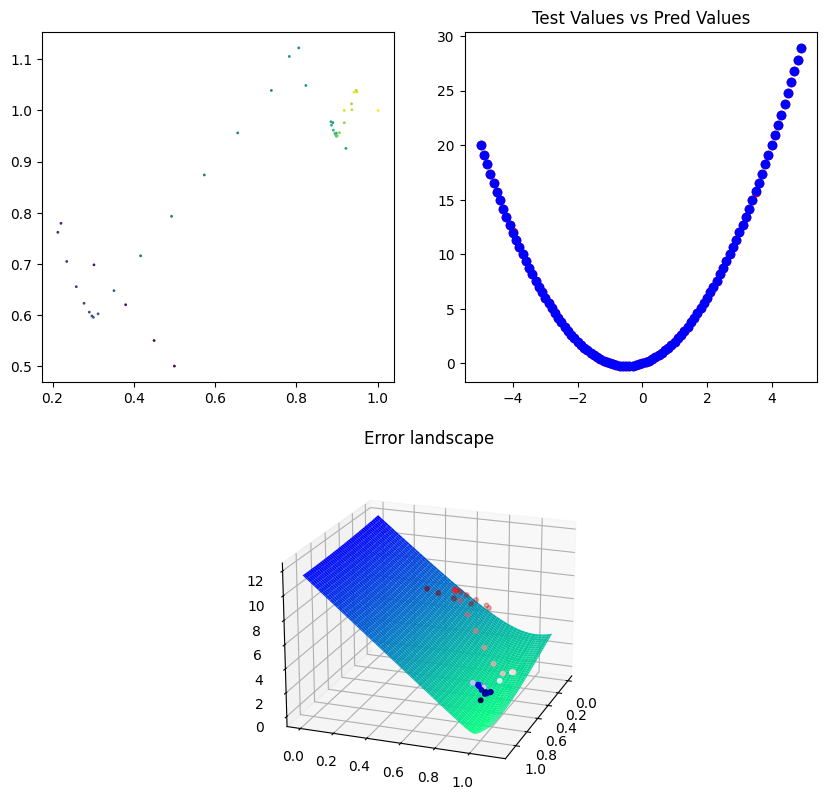

In [16]:
#Nesterov momentum is run separately since I have to run the velocity update separately and it doesn't fit into the main loop
sgd_poly = Polynomial(coefficients=[0.5, 0.5], degrees=[1, 2])
lam = None
optim = NesterovSGD(sgd_poly.get_params(), lr=0.01, momentum=0.4, lr_func=lam)
tol = 0.01
lin_coeffs = []
sq_coeffs = []
lin_term, sq_term = sgd_poly.get_params()
lin_coeffs.append(lin_term.coeff.v)
sq_coeffs.append(sq_term.coeff.v)
steps = 0
stop = False
for i in range(num_epochs):
    if stop==True: break
    batcher = batchmaker(dataset, batch_size)
    for batch, targets in batcher:
        pred_vals = [sgd_poly(point) for point in batch]
        loss = batch_mse(targets, pred_vals)
        optim.gradient_update()
        loss.backward()
        optim.update_params()
        steps += 1
        lin_term, sq_term = sgd_poly.get_params()
        lin_coeffs.append(lin_term.coeff.v)
        sq_coeffs.append(sq_term.coeff.v)
        lin_err = abs(lin_term.coeff.v - true_lin)
        sq_err = abs(sq_term.coeff.v - true_sq)
        if lin_err < tol*true_lin and sq_err < tol*true_sq:
            print(f"Optimization converged at epoch {i+1} with {steps} steps")
            stop = True
            break
if not stop:
    print(f"Optimization did not converge, stopped within {lin_err:.3%} of linear and, {sq_err:.3%} of squared terms with {tol:.3%} tolerance")
plot_vals(lin_coeffs, sq_coeffs, sgd_poly)

# AdaGrad/RMSProp

Optimization converged at epoch 25 with 25 steps


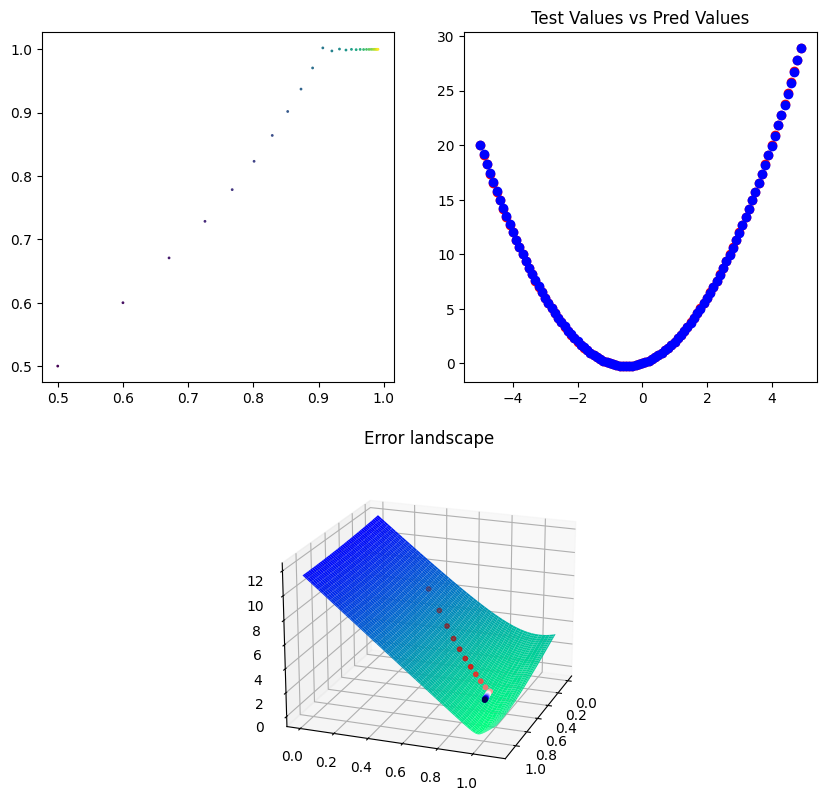

In [17]:
#Fullbatch AdaGrad no Annealing
sgd_poly = Polynomial(coefficients=[0.5, 0.5], degrees=[1, 2])
optim = AdaGrad(sgd_poly.get_params(), lr=0.1, lr_func=None)
run_test(sgd_poly, optim, num_epochs=50)

Optimization converged at epoch 10 with 99 steps


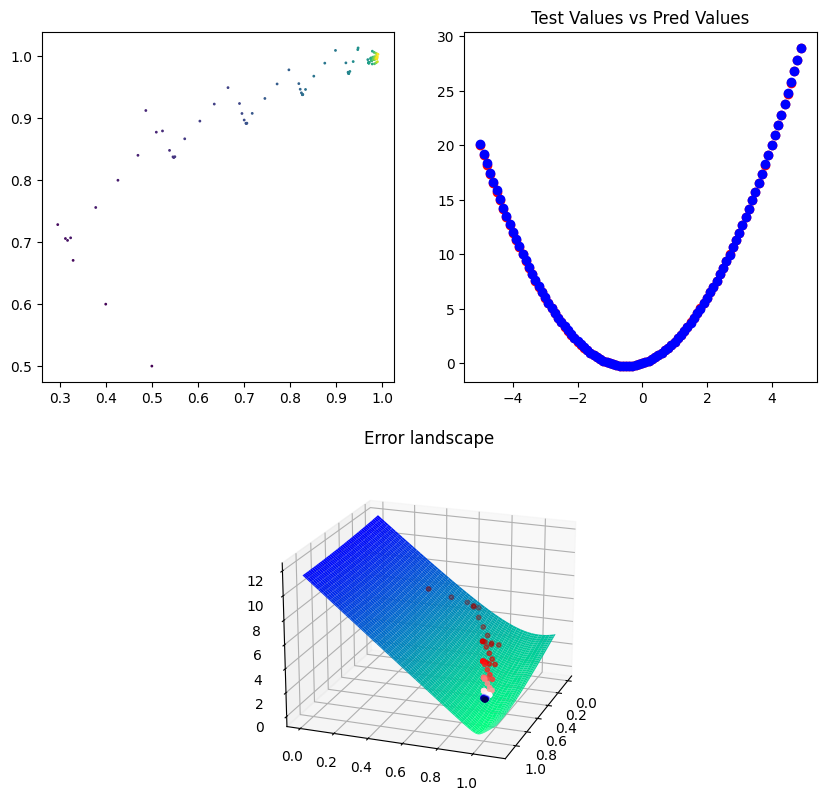

In [18]:
#minibatch AdaGrad no annealing
sgd_poly = Polynomial(coefficients=[0.5, 0.5], degrees=[1, 2])
optim = AdaGrad(sgd_poly.get_params(), lr=0.1, lr_func=None)
run_test(sgd_poly, optim, num_epochs=50, batch_size=10, tol=0.01)

Optimization converged at epoch 18 with 171 steps


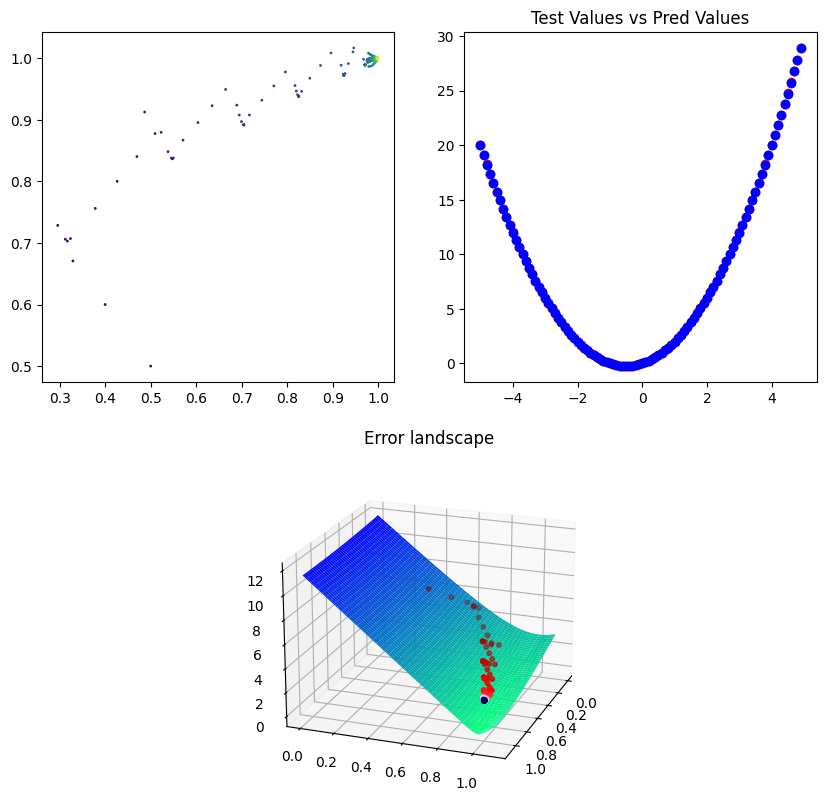

In [19]:
#minibatch AdaGrad with annealing ?????
sgd_poly = Polynomial(coefficients=[0.5, 0.5], degrees=[1, 2])
num_epochs = 40
batch_size = 10
lam = make_lam(num_epochs, batch_size)
optim = AdaGrad(sgd_poly.get_params(), lr=0.1, lr_func=lam)
run_test(sgd_poly, optim, num_epochs=num_epochs, batch_size=batch_size, tol=0.001)

Optimization converged at epoch 26 with 26 steps


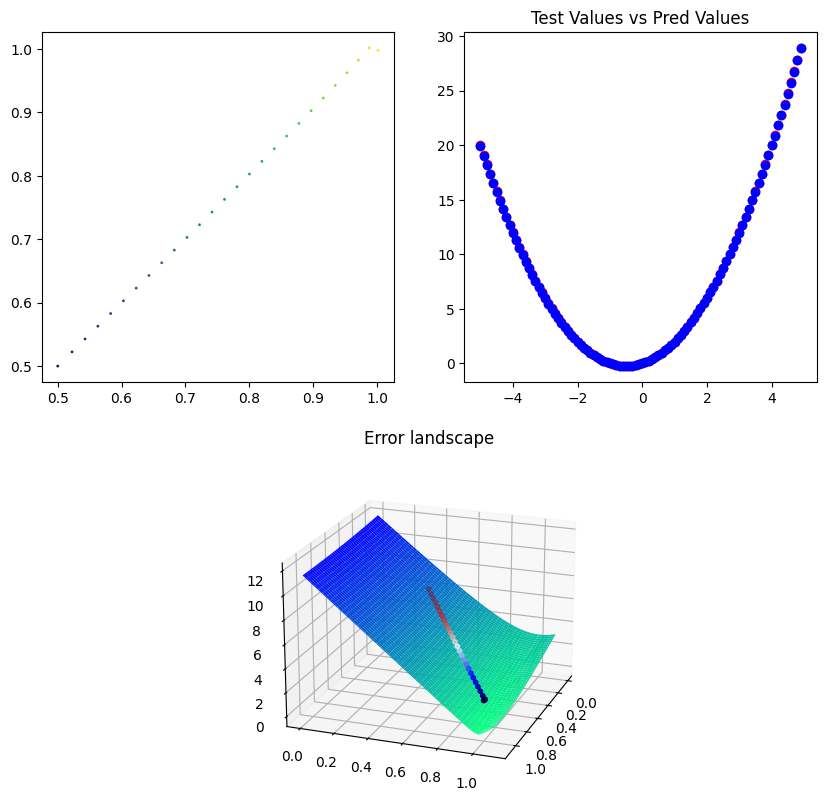

In [48]:
#Full batch RMSProp
sgd_poly = Polynomial(coefficients=[0.5, 0.5], degrees=[1, 2])
optim = RMSProp(sgd_poly.get_params(), lr=0.02, lr_func=lam, beta=0.2)
run_test(sgd_poly, optim, num_epochs=500, tol=0.01)

Optimization converged at epoch 12 with 111 steps


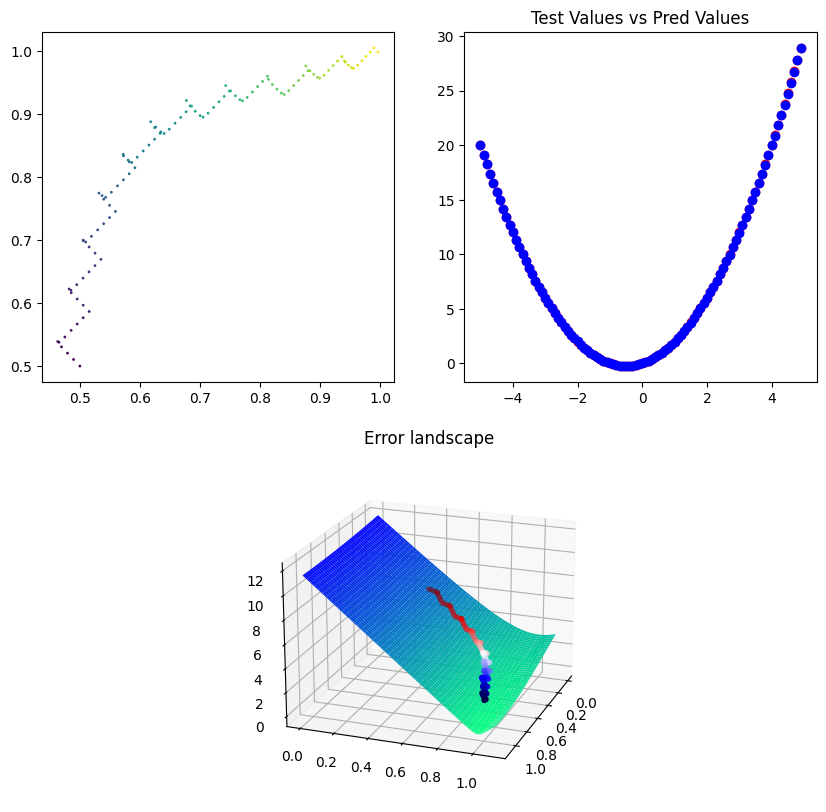

In [53]:
#minibatch RMSProp
sgd_poly = Polynomial(coefficients=[0.5, 0.5], degrees=[1, 2])
num_epochs = 20
batch_size = 10
optim = RMSProp(sgd_poly.get_params(), lr=0.01, lr_func=lam, beta=0.1)
run_test(sgd_poly, optim, num_epochs=num_epochs, batch_size=batch_size, tol=0.01)

Optimization converged at epoch 12 with 12 steps


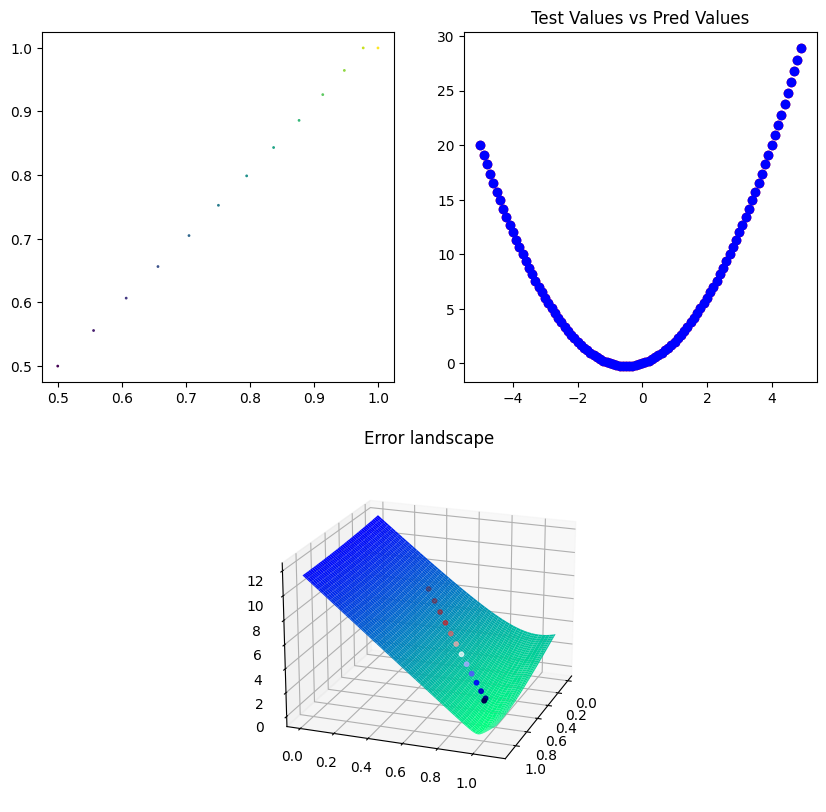

In [90]:
#Full batch RMSProp with Annealing
sgd_poly = Polynomial(coefficients=[0.5, 0.5], degrees=[1, 2])
num_epochs = 20
lam = make_lam(num_epochs)
optim = RMSProp(sgd_poly.get_params(), lr=0.05, lr_func=lam, beta=0.2)
run_test(sgd_poly, optim, num_epochs=num_epochs, tol=0.001)

Optimization converged at epoch 5 with 45 steps


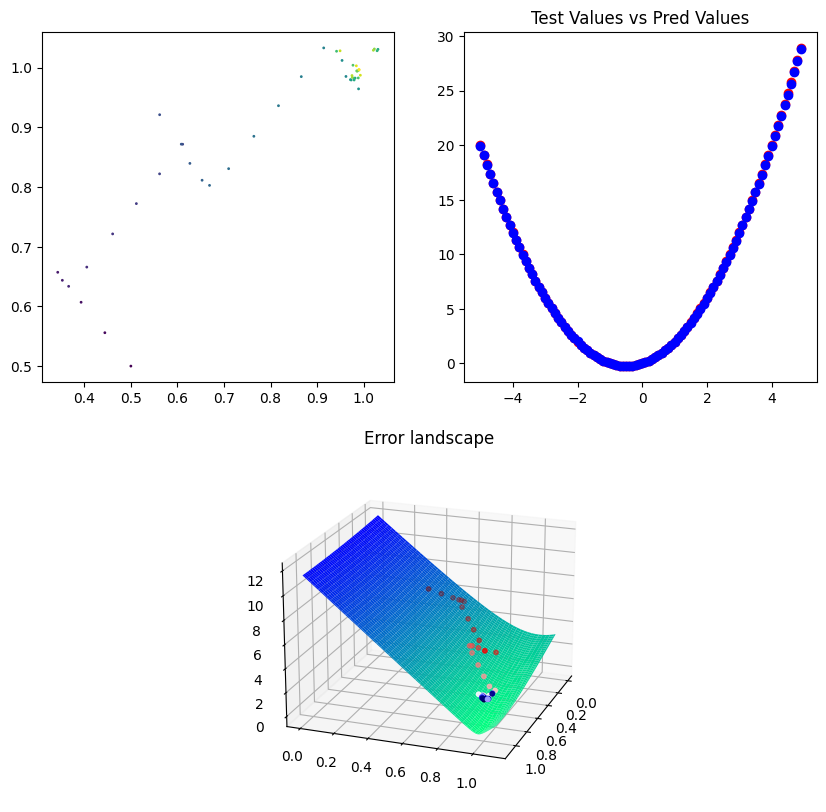

In [92]:
#minibatch RMSProp with Annealing
sgd_poly = Polynomial(coefficients=[0.5, 0.5], degrees=[1, 2])
num_epochs = 15
batch_size = 10
lam = make_lam(num_epochs, num_epochs)
optim = RMSProp(sgd_poly.get_params(), lr=0.05, lr_func=lam, beta=0.2)
run_test(sgd_poly, optim, num_epochs=num_epochs, batch_size=batch_size, tol=0.01)

# Adam